In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FixedLocator
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore")

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 9})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = True

In [3]:
results_file = 'overall.xlsx'

In [4]:
economics_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'economics', index_col = 0)
economics_df_final = economics_df.drop(columns = ['Total', 'Low', 'High'])
economics_df_final

,Scenario,Fossil,Ethylene,Hydrogen,Carbon dioxide,Biogas,Electricity,Heating,Cooling,Other,CAPEX
0,Fossil,1.34,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
1,DAC CO2 + wind H2 + fossil C2H4,0.00,0.426639,0.615149,0.270374,0.000000,0.009119,0.081811,0.005342,0,0.083312
2,Biogas + fossil C2H4,0.00,0.425940,0.208924,0.030434,0.122863,0.016198,0.041171,0.002042,0,0.091809
3,DAC CO2 + wind H2 + green C2H4,0.00,1.989571,0.615149,0.270374,0.000000,0.009119,0.081811,0.005342,0,0.083312
4,Biogas + green C2H4,0.00,1.986314,0.208924,0.030434,0.122863,0.016198,0.041171,0.002042,0,0.091809


In [5]:
x_pts_steps = np.arange(0, len(economics_df_final))
x_labels_steps = ['Fossil', 
                  'DAC CO$_\mathdefault{2}$',
                  'Biogas',
                  'DAC CO$_\mathdefault{2}$',
                  'Biogas',]
colors_steps = ['#808080', '#f94144', '#f3722c', '#f8961e', '#f9c74f', '#90be6d', '#43aa8b', '#4d908e', '#577590', '#277da1'] 

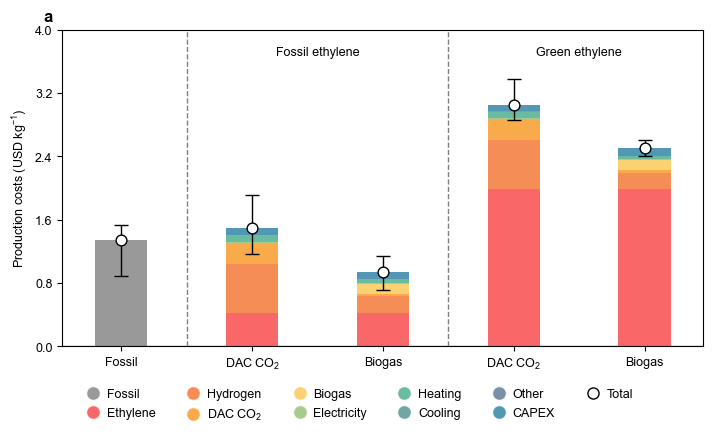

In [6]:
fig, ax1 = plt.subplots(1, 1, figsize = (fig_length[2], fig_height*0.4))

economics_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_steps, alpha=0.8, width=0.4)
ax1.legend([], frameon = False)
ax1.set_ylabel('Production costs (USD kg$^\mathdefault{-1}$)')
ax1.scatter(x_pts_steps, economics_df['Total'], s = 60, facecolor = 'white', edgecolors = '#000000', linewidths=1, zorder=2)
# ax1.scatter(x_pts_steps, economics_df['Impact 2050'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 1)
ax1.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.errorbar(
    x_pts_steps,
    economics_df['Total'],
    yerr = (economics_df['Total'] - economics_df['Low'], economics_df['High'] - economics_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 1,
    capsize = 5,
    capthick = 1,
    zorder = 1,
)
ax1.set_ylim([0.0, 4.0])
# ax1.text(0.5, 1.85, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax1.text(2.5, 1.85, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.set_xticks(x_pts_steps)  
ax1.set_xticklabels(x_labels_steps, rotation = 0)  
ax1.set_title('a', loc='left', x = -0.03, fontsize=12, fontweight='bold')
# ax1.xaxis.set_tick_params(rotation = 45, pad=-2.5)

labels = ['Fossil', 'Ethylene', 'Hydrogen', 'DAC CO$_\mathdefault{2}$', 'Biogas', 'Electricity', 'Heating', 'Cooling', 'Other', 'CAPEX', 'Total']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10, alpha=0.8, linewidth=0.0) for color in colors_steps]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 8, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 8, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 6, frameon = False, handletextpad = 0.1)

ymax = ax1.get_ylim()[1]
ax1.text(1.5, ymax*0.92, 'Fossil ethylene', ha='center', color='#000000', fontsize=9)
ax1.text(3.5, ymax*0.92, 'Green ethylene', ha='center', color='#000000', fontsize=9)

filepath = os.path.join('..', 'results', 'plots', 'economics')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

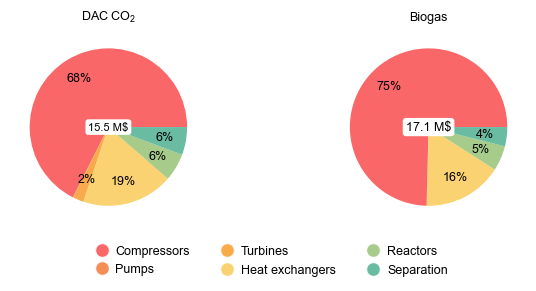

In [29]:
import os
import matplotlib.pyplot as plt

# --- Figure setup ---
fig, axs = plt.subplots(1, 2, figsize=(fig_length[2], fig_height * 0.25))

pie_colors = ['#f94144cc', '#f3722ccc', '#f8961ecc', '#f9c74fcc', '#90be6dcc', '#43aa8bcc']
labels = ['Compressors', 'Pumps', 'Turbines', 'Heat exchangers', 'Reactors', 'Separation']

def autopct_threshold(thresh=2.0, decimals=0):
    """Show percent labels only for slices >= thresh%."""
    fmt = f"{{:.{decimals}f}}%"
    def _autopct(pct):
        return fmt.format(pct) if pct >= thresh else ""
    return _autopct

def add_center_total(ax, total, fontsize=9):
    """Add total in the center with a white rectangle behind."""
    ax.text(
        0, 0, f"{total:.1f} M$",
        ha='center', va='center',
        fontsize=fontsize,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none')
    )

# --- DAC CO2 ---
ax1 = axs[0]
values1 = [7.01, 0.01, 0.23, 1.95, 0.59, 0.59]
ax1.pie(
    values1,
    startangle=0,
    colors=pie_colors,
    autopct=autopct_threshold(thresh=2.0, decimals=0),
    pctdistance=0.72,
    textprops={'fontsize': 9}
)
ax1.set_title('DAC CO$_\\mathdefault{2}$', fontsize=9)
add_center_total(ax1, 15.54, fontsize=8)

# --- Biogas ---
ax2 = axs[1]
values2 = [8.54, 0.01, 0.00, 1.86, 0.59, 0.45]
ax2.pie(
    values2,
    startangle=0,
    colors=pie_colors,
    autopct=autopct_threshold(thresh=2.0, decimals=0),
    pctdistance=0.72,
    textprops={'fontsize': 9}
)
ax2.set_title('Biogas', fontsize=9)
add_center_total(ax2, 17.14, fontsize=9)

# --- Legend ---
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color, markersize=10,
               alpha=0.8, linewidth=0.0)
    for color in pie_colors
]
fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=False,
    handletextpad=0.1
)

fig.tight_layout()

# --- Save ---
out_dir = os.path.join('..', 'results', 'plots')
os.makedirs(out_dir, exist_ok=True)
filepath = os.path.join(out_dir, 'CAPEX')

plt.savefig(filepath + '.png', format='png', bbox_inches='tight', dpi=600)
plt.savefig(filepath + '.svg', format='svg', bbox_inches='tight', dpi=600)

In [8]:
climate_change_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'climate_change_impacts', index_col = 0)
climate_change_df_final = climate_change_df.drop(columns = ['Total', 'Low', 'High', 'STDEV', 'Impact 2050', 'Grave'])
climate_change_df_final

,Scenario,Fossil,Ethylene,Hydrogen,Carbon dioxide,Biogas,Electricity,Heating,Cooling,Other,Direct emissions
0,Fossil,4.421392,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,DAC CO2 + wind H2 + fossil C2H4,0.000000,1.158348,0.213258,-0.685001,0.000000,0.071344,0.613976,0.003975,0.048216,0.022672
2,Biogas + fossil C2H4,0.000000,1.156437,0.072433,-0.077105,-0.472832,0.126728,0.308978,0.001520,0.002123,0.200579
3,DAC CO2 + wind H2 + green C2H4,0.000000,-0.661734,0.213258,-0.685001,0.000000,0.071344,0.613976,0.003975,0.048216,0.022672
4,Biogas + green C2H4,0.000000,-0.660641,0.072433,-0.077105,-0.472832,0.126728,0.308978,0.001520,0.002123,0.200579


In [9]:
human_health_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'human_health_impacts', index_col = 0)
human_health_df_final = human_health_df.drop(columns = ['Total', 'Impact 2050'])
human_health_df_final

ecosystems_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'ecosystem_quality_impacts', index_col = 0)
ecosystems_df_final = ecosystems_df.drop(columns = ['Total', 'Impact 2050'])
ecosystems_df_final

resources_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'natural_resources_impacts', index_col = 0)
resources_df_final = resources_df.drop(columns = ['Total', 'Impact 2050'])
resources_df_final

,Scenario,Fossil,Ethylene,Hydrogen,Carbon dioxide,Biogas,Electricity,Heating,Cooling,Other,Direct emissions
0,Fossil,0.736467,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
1,DAC CO2 + wind H2 + fossil C2H4,0.000000,0.295773,0.019636,0.004334,0.000000,0.002776,0.080695,0.000155,0.032506,2.319836e-09
2,Biogas + fossil C2H4,0.000000,0.295285,0.006669,0.000488,0.005499,0.004930,0.040609,0.000059,0.004322,-2.598435e-10
3,DAC CO2 + wind H2 + green C2H4,0.000000,0.065049,0.019636,0.004334,0.000000,0.002776,0.080695,0.000155,0.032506,2.319836e-09
4,Biogas + green C2H4,0.000000,0.064942,0.006669,0.000488,0.005499,0.004930,0.040609,0.000059,0.004322,-2.598435e-10


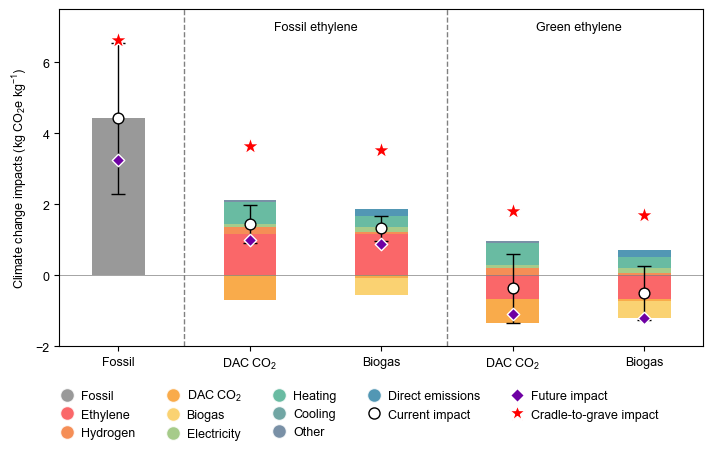

In [10]:
fig, ax1 = plt.subplots(1, 1, figsize = (fig_length[2], fig_height*0.4))

climate_change_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_steps, alpha=0.8, width=0.4)
ax1.legend([], frameon = False)
ax1.set_ylabel('Climate change impacts (kg CO$_\mathdefault{2}$e kg$^\mathdefault{-1}$)')
ax1.scatter(x_pts_steps, climate_change_df['Total'], s = 60, facecolor = 'white', edgecolors = '#000000', linewidths=1, zorder=3)
ax1.scatter(x_pts_steps, climate_change_df['Grave'], s = 180, facecolor = '#ff0000', edgecolors = '#ffffff', marker = '*', zorder=3)
ax1.scatter(x_pts_steps, climate_change_df['Impact 2050'], s = 40, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=3)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.errorbar(
    x_pts_steps,
    climate_change_df['Total'],
    yerr = (climate_change_df['Total'] - climate_change_df['Low'], climate_change_df['High'] - climate_change_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 1,
    capsize = 5,
    capthick = 1,
    zorder = 2,
)
ax1.set_ylim([-2.0, 7.5])
# ax1.text(0.5, 1.85, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax1.text(2.5, 1.85, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.set_xticks(x_pts_steps)  
ax1.set_xticklabels(x_labels_steps, rotation = 0)  
# ax1.set_title('a', loc='left', x = -0.03, fontsize=10, fontweight='bold')
# ax1.xaxis.set_tick_params(rotation = 45, pad=-2.5)

labels = ['Fossil', 'Ethylene', 'Hydrogen', 'DAC CO$_\mathdefault{2}$', 'Biogas', 'Electricity', 'Heating', 'Cooling', 'Other', 'Direct emissions', 'Current impact', 'Future impact', 'Cradle-to-grave impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10, alpha=0.8, linewidth=0.0) for color in colors_steps]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 8, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 7, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = '*', color = 'w', markerfacecolor = '#ff0000', markersize = 12, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 5, frameon = False, handletextpad = 0.1)

ymax = ax1.get_ylim()[1]
ax1.text(1.5, ymax*0.92, 'Fossil ethylene', ha='center', color='#000000', fontsize=9)
ax1.text(3.5, ymax*0.92, 'Green ethylene', ha='center', color='#000000', fontsize=9)

filepath = os.path.join('..', 'results', 'plots', 'climate_change_impacts')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

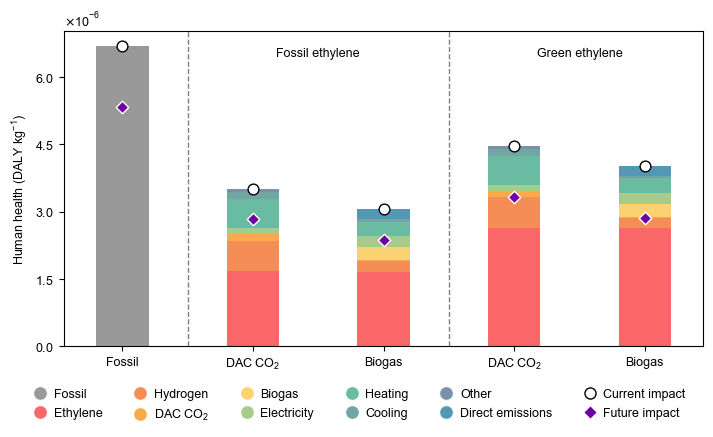

In [11]:
# Human health impacts
fig, ax2 = plt.subplots(1, 1, figsize = (fig_length[2], fig_height*0.4))

human_health_df_final.plot(kind='bar', stacked=True, ax=ax2, color=colors_steps, alpha=0.8, width=0.4)
ax2.legend([], frameon=False)
ax2.set_ylabel('Human health (DALY kg$^\\mathdefault{-1}$)')
ax2.scatter(x_pts_steps, human_health_df['Total'], s=60, facecolor='white', edgecolors='#000000', linewidths=1, zorder=2)
ax2.scatter(x_pts_steps, human_health_df['Impact 2050'], s=40, facecolor='#6e00a3', edgecolors='#ffffff', marker='D', zorder=2)
ax2.axhline(y=0.0, color='#808080', linestyle='-', linewidth=0.5)
ax2.axvline(x=0.5, color='#808080', linestyle='--', linewidth=1)
ax2.axvline(x=2.5, color='#808080', linestyle='--', linewidth=1)

# ax2.set_ylim([-1.0e-6, 3.0e-5])
ax2.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax2.yaxis.set_major_locator(MaxNLocator(5))
ax2.set_xticks(x_pts_steps)
ax2.set_xticklabels(x_labels_steps, rotation=0)

ymax = ax2.get_ylim()[1]
ax2.text(1.5, ymax*0.92, 'Fossil ethylene', ha='center', color='#000000', fontsize=9)
ax2.text(3.5, ymax*0.92, 'Green ethylene', ha='center', color='#000000', fontsize=9)

labels = ['Fossil', 'Ethylene', 'Hydrogen', 'DAC CO$_\mathdefault{2}$', 'Biogas', 'Electricity', 'Heating', 'Cooling', 'Other', 'Direct emissions', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10, alpha=0.8, linewidth=0.0) for color in colors_steps]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 8, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 7, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 6, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'results', 'plots', 'human_health_impacts')
plt.savefig(filepath + '.png', format='png', bbox_inches='tight', dpi=600)
plt.savefig(filepath + '.svg', format='svg', bbox_inches='tight', dpi=600)

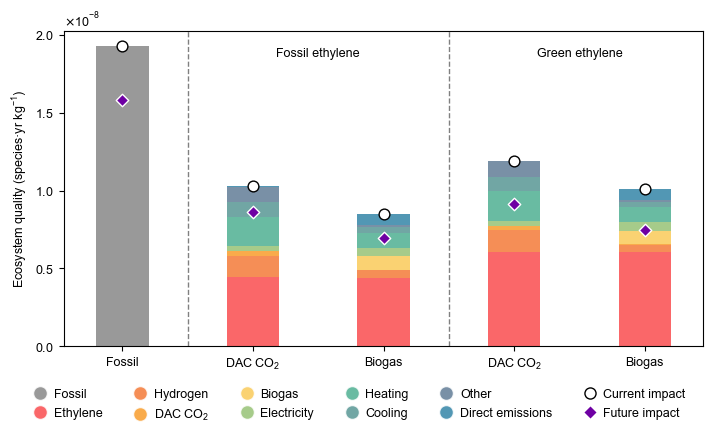

In [12]:
# Ecosystem quality impacts
fig, ax3 = plt.subplots(1, 1, figsize = (fig_length[2], fig_height*0.4))

ecosystems_df_final.plot(kind='bar', stacked=True, ax=ax3, color=colors_steps, alpha=0.8, width=0.4)
ax3.legend([], frameon=False)
ax3.set_ylabel('Ecosystem quality (species·yr kg$^\\mathdefault{-1}$)')
ax3.scatter(x_pts_steps, ecosystems_df['Total'], s=60, facecolor='white', edgecolors='#000000', linewidths=1, zorder=2)
ax3.scatter(x_pts_steps, ecosystems_df['Impact 2050'], s=40, facecolor='#6e00a3', edgecolors='#ffffff', marker='D', zorder=2)
ax3.axhline(y=0.0, color='#808080', linestyle='-', linewidth=0.5)
ax3.axvline(x=0.5, color='#808080', linestyle='--', linewidth=1)
ax3.axvline(x=2.5, color='#808080', linestyle='--', linewidth=1)

# Use scientific notation
ax3.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax3.yaxis.set_major_locator(MaxNLocator(5))
ax3.set_xticks(x_pts_steps)
ax3.set_xticklabels(x_labels_steps, rotation=0)

ymax = ax3.get_ylim()[1]
ax3.text(1.5, ymax*0.92, 'Fossil ethylene', ha='center', color='#000000', fontsize=9)
ax3.text(3.5, ymax*0.92, 'Green ethylene', ha='center', color='#000000', fontsize=9)

labels = ['Fossil', 'Ethylene', 'Hydrogen', 'DAC CO$_\mathdefault{2}$', 'Biogas', 'Electricity', 'Heating', 'Cooling', 'Other', 'Direct emissions', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10, alpha=0.8, linewidth=0.0) for color in colors_steps]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 8, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 7, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 6, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'results', 'plots', 'ecosystem_quality_impacts')
plt.savefig(filepath + '.png', format='png', bbox_inches='tight', dpi=600)
plt.savefig(filepath + '.svg', format='svg', bbox_inches='tight', dpi=600)

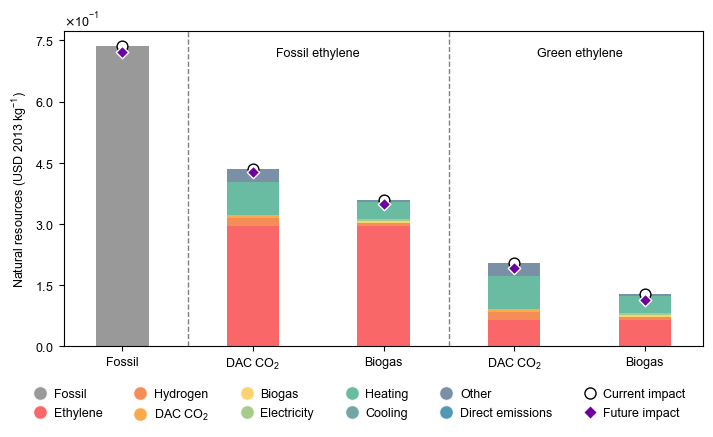

In [13]:
# Natural resources impacts
fig, ax4 = plt.subplots(1, 1, figsize = (fig_length[2], fig_height*0.4))

resources_df_final.plot(kind='bar', stacked=True, ax=ax4, color=colors_steps, alpha=0.8, width=0.4)
ax4.legend([], frameon=False)
ax4.set_ylabel('Natural resources (USD 2013 kg$^\\mathdefault{-1}$)')
ax4.scatter(x_pts_steps, resources_df['Total'], s=60, facecolor='white', edgecolors='#000000', linewidths=1, zorder=2)
ax4.scatter(x_pts_steps, resources_df['Impact 2050'], s=40, facecolor='#6e00a3', edgecolors='#ffffff', marker='D', zorder=2)
ax4.axhline(y=0.0, color='#808080', linestyle='-', linewidth=0.5)
ax4.axvline(x=0.5, color='#808080', linestyle='--', linewidth=1)
ax4.axvline(x=2.5, color='#808080', linestyle='--', linewidth=1)

# Natural resources values may vary widely; enable scientific if needed
ax4.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax4.yaxis.set_major_locator(MaxNLocator(6))
ax4.set_xticks(x_pts_steps)
ax4.set_xticklabels(x_labels_steps, rotation=0)

ymax = ax4.get_ylim()[1]
ax4.text(1.5, ymax*0.92, 'Fossil ethylene', ha='center', color='#000000', fontsize=9)
ax4.text(3.5, ymax*0.92, 'Green ethylene', ha='center', color='#000000', fontsize=9)

labels = ['Fossil', 'Ethylene', 'Hydrogen', 'DAC CO$_\mathdefault{2}$', 'Biogas', 'Electricity', 'Heating', 'Cooling', 'Other', 'Direct emissions', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10, alpha=0.8, linewidth=0.0) for color in colors_steps]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 8, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 7, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 6, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'results', 'plots', 'natural_resources_impacts')
plt.savefig(filepath + '.png', format='png', bbox_inches='tight', dpi=600)
plt.savefig(filepath + '.svg', format='svg', bbox_inches='tight', dpi=600)

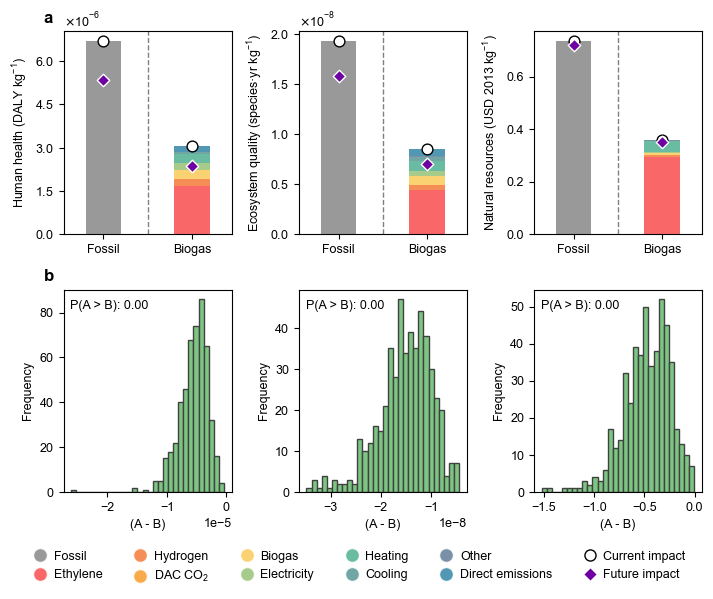

In [14]:
# --- Imports used here ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter

# Keep only row positions 0 and 2
row_sel = [0, 2]

# --- Figure with two rows and three columns ---
fig, axs = plt.subplots(2, 3, figsize=(fig_length[2], fig_height*0.6))

def _prep(df_full, df_final):
    df_final_f = df_final.iloc[row_sel].copy()
    df_full_f  = df_full.iloc[row_sel].copy()
    x_pts_local = np.arange(len(df_final_f.index))
    try:
        x_labels_local = [x_labels_steps[i] for i in row_sel]
    except Exception:
        x_labels_local = df_final_f.index.astype(str).tolist()
    return df_full_f, df_final_f, x_pts_local, x_labels_local

# ===== Row 1: Stacked bars =====
# --- Human health ---
ax = axs[0, 0]
hh_full_f, hh_final_f, x_local, x_labels_local = _prep(human_health_df, human_health_df_final)
hh_final_f.plot(kind='bar', stacked=True, ax=ax, color=colors_steps, alpha=0.8, width=0.4)
ax.legend([], frameon=False)
ax.scatter(x_local, hh_full_f['Total'], s=60, facecolor='white', edgecolors='#000000', linewidths=1, zorder=2)
ax.scatter(x_local, hh_full_f['Impact 2050'], s=40, facecolor='#6e00a3', edgecolors='#ffffff', marker='D', zorder=2)
ax.axvline(x=0.5, color='#808080', linestyle='--', linewidth=1)
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.set_xticks(x_local)
ax.set_xticklabels(x_labels_local, rotation=0)
ax.set_ylabel('Human health (DALY kg$^\\mathdefault{-1}$)')
ax.set_title('a', loc='left', x=-0.12, fontsize=12, fontweight='bold')

# --- Ecosystems ---
ax = axs[0, 1]
eco_full_f, eco_final_f, x_local, x_labels_local = _prep(ecosystems_df, ecosystems_df_final)
eco_final_f.plot(kind='bar', stacked=True, ax=ax, color=colors_steps, alpha=0.8, width=0.4)
ax.legend([], frameon=False)
ax.scatter(x_local, eco_full_f['Total'], s=60, facecolor='white', edgecolors='#000000', linewidths=1, zorder=2)
ax.scatter(x_local, eco_full_f['Impact 2050'], s=40, facecolor='#6e00a3', edgecolors='#ffffff', marker='D', zorder=2)
ax.axvline(x=0.5, color='#808080', linestyle='--', linewidth=1)
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.set_xticks(x_local)
ax.set_xticklabels(x_labels_local, rotation=0)
ax.set_ylabel('Ecosystem quality (species·yr kg$^\\mathdefault{-1}$)')

# --- Resources ---
ax = axs[0, 2]
res_full_f, res_final_f, x_local, x_labels_local = _prep(resources_df, resources_df_final)
res_final_f.plot(kind='bar', stacked=True, ax=ax, color=colors_steps, alpha=0.8, width=0.4)
ax.legend([], frameon=False)
ax.scatter(x_local, res_full_f['Total'], s=60, facecolor='white', edgecolors='#000000', linewidths=1, zorder=2)
ax.scatter(x_local, res_full_f['Impact 2050'], s=40, facecolor='#6e00a3', edgecolors='#ffffff', marker='D', zorder=2)
ax.axvline(x=0.5, color='#808080', linestyle='--', linewidth=1)
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.set_xticks(x_local)
ax.set_xticklabels(x_labels_local, rotation=0)
ax.set_ylabel('Natural resources (USD 2013 kg$^\\mathdefault{-1}$)')

# --- Restore scientific notation on y for Human health and Ecosystems only ---
for ax in (axs[0, 0], axs[0, 1]):
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(fmt)
    ax.ticklabel_format(axis='y', style='sci')

# ===== Row 2: Histograms (Monte Carlo) =====
# Read MC inputs into distinct variables
human_health_mc = pd.read_excel(os.path.join('..', 'results', 'human_health_monte_carlo.xlsx'),
                                sheet_name='Sheet1', index_col=0)
ecosystem_quality_mc = pd.read_excel(os.path.join('..', 'results', 'ecosystem_quality_monte_carlo.xlsx'),
                                     sheet_name='Sheet1', index_col=0)
natural_resources_mc = pd.read_excel(os.path.join('..', 'results', 'natural_resources_monte_carlo.xlsx'),
                                     sheet_name='Sheet1', index_col=0)

# --- HH histogram ---
ax = axs[1, 0]
data = (human_health_mc['propanol production, biogas, fossil ethylene'].values
        - human_health_mc['propanol production, fossil'].values)
n, bins_arr, patches = ax.hist(data, bins=30, alpha=1, edgecolor='#414141')
for i in range(len(patches)):
    if bins_arr[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
positive_prob = (data > 0).sum() / len(data)
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes, va='top')
ax.set_xlabel('(A - B)')
ax.set_ylabel('Frequency')
ax.set_title('b', loc='left', x=-0.12, fontsize=12, fontweight='bold')

# --- EQ histogram ---
ax = axs[1, 1]
data = (ecosystem_quality_mc['propanol production, biogas, fossil ethylene'].values
        - ecosystem_quality_mc['propanol production, fossil'].values)
n, bins_arr, patches = ax.hist(data, bins=30, alpha=1, edgecolor='#414141')
for i in range(len(patches)):
    if bins_arr[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
positive_prob = (data > 0).sum() / len(data)
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes, va='top')
ax.set_xlabel('(A - B)')
ax.set_ylabel('Frequency')

# --- NR histogram ---
ax = axs[1, 2]
data = (natural_resources_mc['propanol production, biogas, fossil ethylene'].values
        - natural_resources_mc['propanol production, fossil'].values)
n, bins_arr, patches = ax.hist(data, bins=30, alpha=1, edgecolor='#414141')
for i in range(len(patches)):
    if bins_arr[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
positive_prob = (data > 0).sum() / len(data)
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes, va='top')
ax.set_xlabel('(A - B)')
ax.set_ylabel('Frequency')

# ===== Figure legend for row 1 semantics =====
labels = ['Fossil', 'Ethylene', 'Hydrogen', 'DAC CO$_\\mathdefault{2}$', 'Biogas',
          'Electricity', 'Heating', 'Cooling', 'Other', 'Direct emissions',
          'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                      markersize=10, alpha=0.8, linewidth=0.0) for color in colors_steps]
handles += [plt.Line2D([0], [0], marker='o', color='k', markerfacecolor='#ffffff',
                       markersize=8, linewidth=0.0)]
handles += [plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#6e00a3',
                       markersize=7, linewidth=0.0)]
fig.legend(handles=handles, labels=labels, loc='upper center',
           bbox_to_anchor=(0.5, 0.07), ncol=6, frameon=False, handletextpad=0.1)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# Save once
filepath = os.path.join('..', 'results', 'plots', 'impact_plus_burden_shifting_two_rows')
plt.savefig(filepath + '.png', format='png', bbox_inches='tight', dpi=600)
plt.savefig(filepath + '.svg', format='svg', bbox_inches='tight', dpi=600)

In [15]:
cliamte_change_2050_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'climate_change_impacts_2050', index_col = 0)
cliamte_change_2050_df_final = cliamte_change_2050_df.drop(columns = ['Total'])
cliamte_change_2050_df_final

,Scenario,Fossil,Ethylene,Hydrogen,Carbon dioxide,Biogas,Electricity,Heating,Cooling,Other,Direct emissions
0,Fossil,3.233107,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,DAC CO2 + wind H2 + fossil C2H4,0.000000,0.911403,0.129723,-0.703993,0.000000,0.000634,0.597291,0.000035,0.033488,0.022672
2,Biogas + fossil C2H4,0.000000,0.909898,0.044060,-0.079243,-0.512149,0.001127,0.300581,0.000014,0.001473,0.200579
3,DAC CO2 + wind H2 + green C2H4,0.000000,-1.174882,0.129723,-0.703993,0.000000,0.000634,0.597291,0.000035,0.033488,0.022672
4,Biogas + green C2H4,0.000000,-1.172942,0.044060,-0.079243,-0.512149,0.001127,0.300581,0.000014,0.001473,0.200579


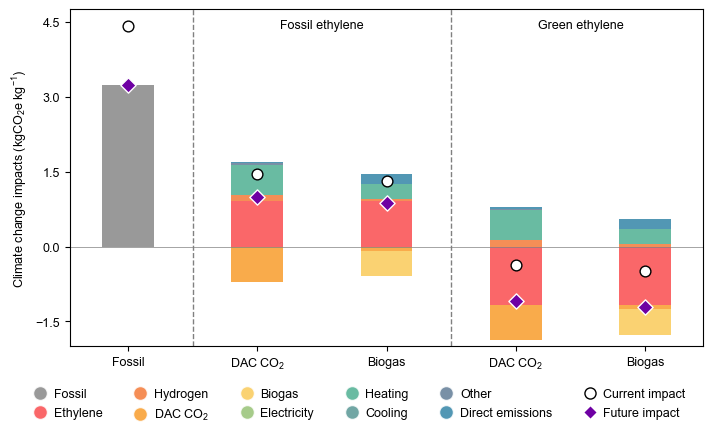

In [16]:
fig, ax1 = plt.subplots(1, 1, figsize = (fig_length[2], fig_height*0.4))

cliamte_change_2050_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_steps, alpha=0.8, width=0.4)
ax1.legend([], frameon = False)
ax1.set_ylabel('Climate change impacts (kgCO$_\mathdefault{2}$e kg$^\mathdefault{-1}$)')
ax1.scatter(x_pts_steps, climate_change_df['Total'], s = 60, facecolor = 'white', edgecolors = '#000000', linewidths=1, zorder=2)
ax1.scatter(x_pts_steps, cliamte_change_2050_df['Total'], s = 60, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.set_ylim([-2.0, 4.75])
# ax1.text(0.5, 1.85, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax1.text(2.5, 1.85, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.set_xticks(x_pts_steps)  
ax1.set_xticklabels(x_labels_steps, rotation = 0) 

labels = ['Fossil', 'Ethylene', 'Hydrogen', 'DAC CO$_\mathdefault{2}$', 'Biogas', 'Electricity', 'Heating', 'Cooling', 'Other', 'Direct emissions', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10, alpha=0.8, linewidth=0.0) for color in colors_steps]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 8, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 7, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 6, frameon = False, handletextpad = 0.1)

ymax = ax1.get_ylim()[1]
ax1.text(1.5, ymax*0.92, 'Fossil ethylene', ha='center', color='#000000', fontsize=9)
ax1.text(3.5, ymax*0.92, 'Green ethylene', ha='center', color='#000000', fontsize=9)

filepath = os.path.join('..', 'results', 'plots', 'climate_change_impacts_2050')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

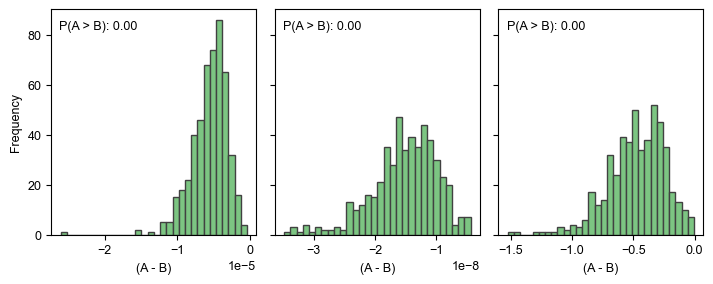

In [17]:
human_health_df = pd.read_excel(os.path.join('..', 'results', 'human_health_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)
ecosystem_quality_df = pd.read_excel(os.path.join('..', 'results', 'ecosystem_quality_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)
natural_resources_df = pd.read_excel(os.path.join('..', 'results', 'natural_resources_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)

fig, axs = plt.subplots(1, 3, figsize=(fig_length[2], fig_height*0.3), sharey=True)

ax = axs[0]
data = human_health_df['propanol production, biogas, fossil ethylene'].values - human_health_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')

# ['#f94144cc', '#f3722ccc', '#f8961ecc', '#f9c74fcc', '#90be6dcc', '#43aa8bcc']
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
# ax.set_title('Human health (DALY kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')
ax.set_ylabel('Frequency')

ax = axs[1]
data = ecosystem_quality_df['propanol production, biogas, fossil ethylene'].values - ecosystem_quality_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
# ax.set_title('Ecosystem quality (species.yr kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')

ax = axs[2]
data = natural_resources_df['propanol production, biogas, fossil ethylene'].values - natural_resources_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
# ax.set_title('Natural resources (USD 2013 kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')

filepath = os.path.join('..', 'results', 'plots', 'burden_shifting')
plt.savefig(filepath + '.png', format='png', bbox_inches='tight', dpi=600)
plt.savefig(filepath + '.svg', format='svg', bbox_inches='tight', dpi=600)

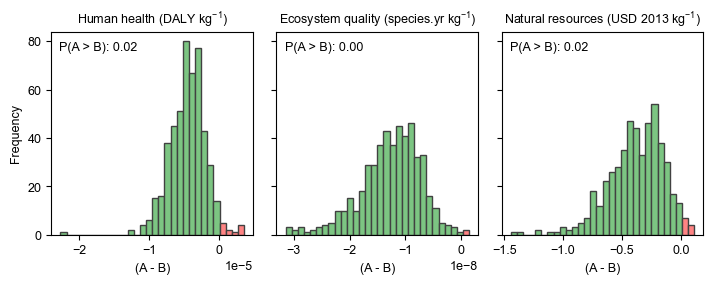

In [18]:
human_health_df = pd.read_excel(os.path.join('..', 'results', 'human_health_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)
ecosystem_quality_df = pd.read_excel(os.path.join('..', 'results', 'ecosystem_quality_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)
natural_resources_df = pd.read_excel(os.path.join('..', 'results', 'natural_resources_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)

fig, axs = plt.subplots(1, 3, figsize=(fig_length[2], fig_height*0.3), sharey=True)

ax = axs[0]
data = human_health_df['propanol production, DAC carbon dioxide, wind hydrogen, fossil ethylene'].values - human_health_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')

# ['#f94144cc', '#f3722ccc', '#f8961ecc', '#f9c74fcc', '#90be6dcc', '#43aa8bcc']
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Human health (DALY kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')
ax.set_ylabel('Frequency')

ax = axs[1]
data = ecosystem_quality_df['propanol production, DAC carbon dioxide, wind hydrogen, fossil ethylene'].values - ecosystem_quality_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Ecosystem quality (species.yr kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')

ax = axs[2]
data = natural_resources_df['propanol production, DAC carbon dioxide, wind hydrogen, fossil ethylene'].values - natural_resources_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Natural resources (USD 2013 kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')

filepath = os.path.join('..', 'results', 'plots', 'burden_shifting_DAC_fossil_ethylene')
plt.savefig(filepath + '.png', format='png', bbox_inches='tight', dpi=600)
plt.savefig(filepath + '.svg', format='svg', bbox_inches='tight', dpi=600)

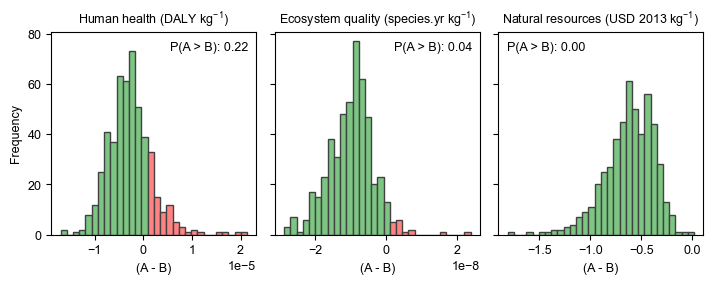

In [19]:
human_health_df = pd.read_excel(os.path.join('..', 'results', 'human_health_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)
ecosystem_quality_df = pd.read_excel(os.path.join('..', 'results', 'ecosystem_quality_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)
natural_resources_df = pd.read_excel(os.path.join('..', 'results', 'natural_resources_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)

fig, axs = plt.subplots(1, 3, figsize=(fig_length[2], fig_height*0.3), sharey=True)

ax = axs[0]
data = human_health_df['propanol production, DAC carbon dioxide, wind hydrogen, green ethylene'].values - human_health_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')

# ['#f94144cc', '#f3722ccc', '#f8961ecc', '#f9c74fcc', '#90be6dcc', '#43aa8bcc']
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.58, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Human health (DALY kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')
ax.set_ylabel('Frequency')

ax = axs[1]
data = ecosystem_quality_df['propanol production, DAC carbon dioxide, wind hydrogen, green ethylene'].values - ecosystem_quality_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.58, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Ecosystem quality (species.yr kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')

ax = axs[2]
data = natural_resources_df['propanol production, DAC carbon dioxide, wind hydrogen, green ethylene'].values - natural_resources_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Natural resources (USD 2013 kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')

filepath = os.path.join('..', 'results', 'plots', 'burden_shifting_DAC_green_ethylene')
plt.savefig(filepath + '.png', format='png', bbox_inches='tight', dpi=600)
plt.savefig(filepath + '.svg', format='svg', bbox_inches='tight', dpi=600)

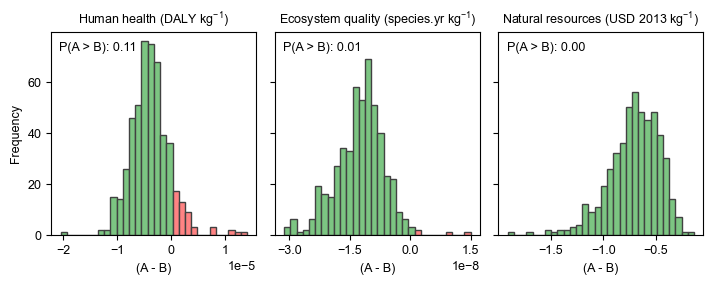

In [20]:
human_health_df = pd.read_excel(os.path.join('..', 'results', 'human_health_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)
ecosystem_quality_df = pd.read_excel(os.path.join('..', 'results', 'ecosystem_quality_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)
natural_resources_df = pd.read_excel(os.path.join('..', 'results', 'natural_resources_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)

fig, axs = plt.subplots(1, 3, figsize=(fig_length[2], fig_height*0.3), sharey=True)

ax = axs[0]
data = human_health_df['propanol production, biogas, green ethylene'].values - human_health_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')

# ['#f94144cc', '#f3722ccc', '#f8961ecc', '#f9c74fcc', '#90be6dcc', '#43aa8bcc']
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Human health (DALY kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')
ax.set_ylabel('Frequency')
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.xaxis.set_major_locator(MaxNLocator(4))

ax = axs[1]
data = ecosystem_quality_df['propanol production, biogas, green ethylene'].values - ecosystem_quality_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Ecosystem quality (species.yr kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.xaxis.set_major_locator(MaxNLocator(4))

ax = axs[2]
data = natural_resources_df['propanol production, biogas, green ethylene'].values - natural_resources_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Natural resources (USD 2013 kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.xaxis.set_major_locator(MaxNLocator(4))

filepath = os.path.join('..', 'results', 'plots', 'burden_shifting_biogas_green_ethylene')
plt.savefig(filepath + '.png', format='png', bbox_inches='tight', dpi=600)
plt.savefig(filepath + '.svg', format='svg', bbox_inches='tight', dpi=600)

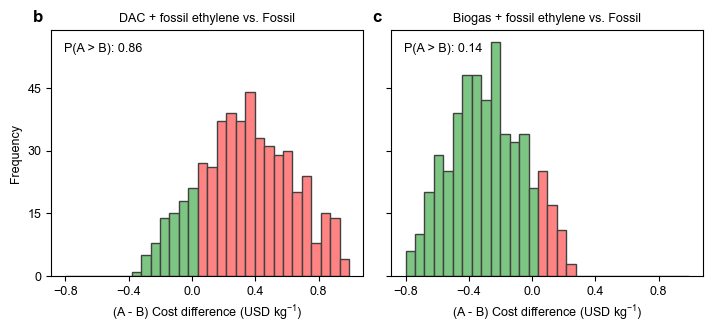

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import MaxNLocator  # make sure this import is present

# ==== Monte Carlo Simulation ====
iterations = 500

fossil_low, fossil_high = 0.89, 1.53
biogas_low, biogas_high = 0.709, 1.147
dac_low, dac_high = 1.169, 1.914

rng = np.random.default_rng(seed=42)  # For reproducibility
fossil_samples = rng.uniform(fossil_low, fossil_high, iterations)
biogas_samples = rng.uniform(biogas_low, biogas_high, iterations)
dac_samples    = rng.uniform(dac_low, dac_high, iterations)

data     = biogas_samples - fossil_samples
dac_data = dac_samples - fossil_samples

positive_prob     = (data > 0).sum() / len(data)
positive_prob_dac = (dac_data > 0).sum() / len(dac_data)

# ---- Common bin EDGES (same bar widths) ----
bins_n = 30
all_data = np.concatenate([dac_data, data])
bin_edges = np.linspace(all_data.min(), all_data.max(), bins_n + 1)

# ==== Plot ====
fig, axs = plt.subplots(1, 2, figsize=(fig_length[2], fig_height*0.35), sharey=True, sharex=True)

# --- DAC subplot ---
ax = axs[0]
n, bins_arr, patches = ax.hist(dac_data, bins=bin_edges, alpha=1, edgecolor='#414141')
for i, p in enumerate(patches):
    p.set_facecolor('#ff8383' if bins_arr[i] > 0 else '#7cc582')
ax.text(0.04, 0.95, f'P(A > B): {positive_prob_dac:.2f}', transform=ax.transAxes, va='top')
ax.set_title('DAC + fossil ethylene vs. Fossil', fontsize=9)
ax.set_xlabel('(A - B) Cost difference (USD kg$^\\mathdefault{-1}$)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_locator(MaxNLocator(5))
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.set_title('b', loc='left', x=-0.06, fontsize=12, fontweight='bold')

# --- Biogas subplot ---
ax = axs[1]
n, bins_arr, patches = ax.hist(data, bins=bin_edges, alpha=1, edgecolor='#414141')
for i, p in enumerate(patches):
    p.set_facecolor('#ff8383' if bins_arr[i] > 0 else '#7cc582')
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes, va='top')
ax.set_title('Biogas + fossil ethylene vs. Fossil', fontsize=9)
ax.set_xlabel('(A - B) Cost difference (USD kg$^\\mathdefault{-1}$)')
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.set_title('c', loc='left', x=-0.06, fontsize=12, fontweight='bold')
# ax.set_ylim(0, 63)

# Save plot
output_dir = os.path.join('..', 'results', 'plots')
os.makedirs(output_dir, exist_ok=True)
filepath = os.path.join(output_dir, 'monte_carlo_cost')
plt.savefig(filepath + '.png', format='png', bbox_inches='tight', dpi=600)
plt.savefig(filepath + '.svg', format='svg', bbox_inches='tight', dpi=600)